<div class="alert alert-block alert-info">
<center><strong> Predicting Urban vs. Rural Household Classification using Supervised Machine Learning </strong></center>
</div>

<hr/>
<center> A major course output (MCO) in completing 20% of final grade in Advanced Intelligent Systems (STINTSY) </center> 

Term 2 A.Y. 2025-2026
<br/>
**Group #2 CSINTSY Survivors (Section S18)**

| Member Name | Contributions |
| ----- | -----  |
| Chavez, Allen Visagar | text  |
| Llanes, Andre Gabriel De Ocampo  | text  |
| Rojo, Von Matthew De Guzman *(leader)* | text |
| Tan, Jeremy James Teves | text |

Professor: Antioquia, Arren Matthew Capuchino

**Project Objective:** The primary objective of this project is to develop and evaluate supervised machine learning models capable of predicting whether a family resides in an Urban or Rural area (URB).
<br/><br/>
This project utilizes a comprehensive set of socioeconomic and structural features from the Family Income and Expenditure Survey (FIES) dataset, including:
* **Housing Characteristics:** Building type, roof material, wall material, toilet facilities, electricity access, and main water source.
* **Financial Indicators:** Total income, total expenditures, food and non-food expenses, and rent values (actual and imputed).
* **Asset Ownership:** Quantities of owned assets such as cars, televisions, personal computers, air conditioners, and other household appliances.
<br/><br/>

**Methodology:** As part of the STINTSY Major Course Output (MCO), we will perform end-to-end machine learning pipeline development, starting with Data Preparation and Exploratory Data Analysis (EDA). Ultimately, we will implement and compare the performance of at least three supervised machine learning models (two classical machine learning models and one neural network) to determine the most effective approach for this classification task.
<hr/>

In [2]:
## Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np # for importing datasets
import math
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

%load_ext autoreload
%autoreload 2
from MCO_functions import *

# **[1]** Data Preparation
**Dataset Name:** Family Income and Expenditure Survey 2012 Vol 1
<br/>
**Accessed from:** [click this link](https://psada.psa.gov.ph/catalog/38/data-dictionary/F2?file_name=fies2012_v1)

In [3]:
csv_path = 'feis_dataset/FIES PUF 2012 Vol.1.CSV'
csvdict_path = 'feis_dataset/fies_2012_v1_metadata(dictionary)'
fies_original_df = pd.read_csv(csv_path)

fies_original_df

,W_REGN,W_OID,W_SHSN,W_HCN,URB,RSTR,PSU,BWEIGHT,RFACT,FSIZE,...,PC_QTY,OVEN_QTY,MOTOR_BANCA_QTY,MOTORCYCLE_QTY,POP_ADJ,PCINC,NATPC,NATDC,REGDC,REGPC
0,14,101001000,2,25,2,21100,415052,138.25,200.6576,3.0,...,01,01,,,0.946172,108417.00,9,8,8,9
1,14,101001000,3,43,2,21100,415052,138.25,200.6576,12.5,...,,01,,01,0.946172,30631.60,5,9,9,4
2,14,101001000,4,62,2,21100,415052,138.25,200.6576,2.0,...,,01,,,0.946172,86992.50,9,6,6,8
3,14,101001000,5,79,2,21100,415052,138.25,200.6576,4.0,...,,01,,,0.946172,43325.75,6,6,6,6
4,14,101001000,10,165,2,21100,415052,138.25,200.6576,5.0,...,,,,01,0.946172,37481.80,6,6,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40166,12,9804029001,18,568,1,22000,114062,271.25,963.2264,5.0,...,00,00,00,00,0.902863,30101.60,5,5,7,7
40167,12,9804035000,1,25,2,22000,414067,271.25,588.6253,9.0,...,00,01,00,00,0.902863,14368.89,1,5,7,3
40168,12,9804035000,2,51,2,22000,414067,271.25,588.6253,6.0,...,00,00,00,00,0.902863,19137.33,3,4,6,4
40169,12,9804035000,3,75,2,22000,414067,271.25,588.6253,5.0,...,00,01,00,00,0.902863,30985.00,5,6,7,7


Use only selected features to lessen size

In [4]:
selected_features = [
    'URB', # Target Variable
    'W_REGN', 'BLDG_TYPE', 'ROOF', 'WALLS', 'TOILET', 'ELECTRIC', 'WATER',
    'NET_RECEIPT', 'REGFT', 'EAINC', 'TOINC', 'T_FOOD_HOME', 'T_FOOD', 
    'T_CLOTH', 'T_HEALTH', 'T_HOUSING_WATER', 'T_RENTVAL', 'T_IMPUTED_RENT', 
    'T_COMMUNICATION', 'T_BREAD', 'T_MEAT', 'T_FISH', 'T_MILK', 'T_OIL', 'T_FRUIT', 
    'T_VEG', 'T_SUGAR', 'T_FOOD_NEC', 'T_COFFEE', 'T_MINERAL', 'T_NFOOD', 
    'T_TOTEX', 'T_TOTDIS', 'CAR_QTY', 'MOTORCYCLE_QTY', 'PC_QTY', 
    'LANDLINE_QTY', 'CELLPHONE_QTY', 'TV_QTY', 'RADIO_QTY', 'AIRCON_QTY', 
    'WASH_QTY', 'REF_QTY'
]

fies_subset_df = fies_original_df[selected_features].copy()
fies_subset_df

,URB,W_REGN,BLDG_TYPE,ROOF,WALLS,TOILET,ELECTRIC,WATER,NET_RECEIPT,REGFT,...,CAR_QTY,MOTORCYCLE_QTY,PC_QTY,LANDLINE_QTY,CELLPHONE_QTY,TV_QTY,RADIO_QTY,AIRCON_QTY,WASH_QTY,REF_QTY
0,2,14,1,1,1,1,1,1,4385,76666,...,,,01,,02,01,01,,01,01
1,2,14,1,5,5,3,1,1,1350,369,...,,01,,,03,01,01,,,
2,2,14,2,1,1,1,1,1,1625,14830,...,01,,,,01,01,01,01,,01
3,2,14,1,1,1,1,1,6,7649,29394,...,,,,,02,01,01,,02,01
4,2,14,1,1,1,1,1,1,7359,130,...,,01,,,01,01,01,,01,01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40166,1,12,1,1,1,1,1,1,0,140,...,00,00,00,00,02,01,01,00,00,00
40167,2,12,1,1,1,0,1,2,0,620,...,00,00,00,00,01,01,00,00,00,00
40168,2,12,1,2,2,0,1,2,1170,540,...,00,00,00,00,01,01,01,00,00,00
40169,2,12,1,1,1,2,1,2,1664,0,...,00,00,00,00,02,01,01,00,00,00


Some data cleaning... puro 01 at 00 yung PC_QTY and others.

In [5]:
qty_columns = [
    'CAR_QTY', 'MOTORCYCLE_QTY', 'PC_QTY', 'LANDLINE_QTY', 
    'CELLPHONE_QTY', 'TV_QTY', 'RADIO_QTY', 'AIRCON_QTY', 
    'WASH_QTY', 'REF_QTY'
]

# Clean and convert the columns
for col in qty_columns:
    # Convert to string, strip whitespace, and replace empty strings with '0'
    fies_subset_df[col] = fies_subset_df[col].astype(str).str.strip().replace('', '0')
    
    # Convert the column to numeric. Any weird unparseable values become NaN (errors='coerce')
    fies_subset_df[col] = pd.to_numeric(fies_subset_df[col], errors='coerce')
    
    # Fill any remaining NaNs with 0, then cast the whole column to integer
    fies_subset_df[col] = fies_subset_df[col].fillna(0).astype(int)

fies_subset_df

,URB,W_REGN,BLDG_TYPE,ROOF,WALLS,TOILET,ELECTRIC,WATER,NET_RECEIPT,REGFT,...,CAR_QTY,MOTORCYCLE_QTY,PC_QTY,LANDLINE_QTY,CELLPHONE_QTY,TV_QTY,RADIO_QTY,AIRCON_QTY,WASH_QTY,REF_QTY
0,2,14,1,1,1,1,1,1,4385,76666,...,0,0,1,0,2,1,1,0,1,1
1,2,14,1,5,5,3,1,1,1350,369,...,0,1,0,0,3,1,1,0,0,0
2,2,14,2,1,1,1,1,1,1625,14830,...,1,0,0,0,1,1,1,1,0,1
3,2,14,1,1,1,1,1,6,7649,29394,...,0,0,0,0,2,1,1,0,2,1
4,2,14,1,1,1,1,1,1,7359,130,...,0,1,0,0,1,1,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40166,1,12,1,1,1,1,1,1,0,140,...,0,0,0,0,2,1,1,0,0,0
40167,2,12,1,1,1,0,1,2,0,620,...,0,0,0,0,1,1,0,0,0,0
40168,2,12,1,2,2,0,1,2,1170,540,...,0,0,0,0,1,1,1,0,0,0
40169,2,12,1,1,1,2,1,2,1664,0,...,0,0,0,0,2,1,1,0,0,0


check for null values or whitespaces

In [6]:
# check if there is any null values or whitespaces
ws_or_na_df = fies_subset_df.replace(r'^\s*$', pd.NA, regex=True)
ws_or_na_ctr = ws_or_na_df.isna().sum()

print("Whitespaces or null value counts: ")
print(ws_or_na_ctr.to_string())

Whitespaces or null value counts: 
URB                0
W_REGN             0
BLDG_TYPE          0
ROOF               0
WALLS              0
TOILET             0
ELECTRIC           0
WATER              0
NET_RECEIPT        0
REGFT              0
EAINC              0
TOINC              0
T_FOOD_HOME        0
T_FOOD             0
T_CLOTH            0
T_HEALTH           0
T_HOUSING_WATER    0
T_RENTVAL          0
T_IMPUTED_RENT     0
T_COMMUNICATION    0
T_BREAD            0
T_MEAT             0
T_FISH             0
T_MILK             0
T_OIL              0
T_FRUIT            0
T_VEG              0
T_SUGAR            0
T_FOOD_NEC         0
T_COFFEE           0
T_MINERAL          0
T_NFOOD            0
T_TOTEX            0
T_TOTDIS           0
CAR_QTY            0
MOTORCYCLE_QTY     0
PC_QTY             0
LANDLINE_QTY       0
CELLPHONE_QTY      0
TV_QTY             0
RADIO_QTY          0
AIRCON_QTY         0
WASH_QTY           0
REF_QTY            0


check for any duplicates

In [7]:
# check if there are any duplicates
dupes = fies_subset_df.duplicated().sum()

if (dupes <= 0):
  print('There are no duplicates')
else:
  print('There are', dupes, 'duplicates')

There are no duplicates


# **[2]** Exploratory Data Analysis (EDA)
This phase allows exploration of datasets and check any anomalies present.
1. Basic Dataset Information
2. Urban and Rural Comparative Statistics

# **[2.1]** Basic Dataset Information
- column statistics

In [8]:
# summary for all columns
description = fies_subset_df.describe().T
print(description.to_string())

                   count           mean            std     min      25%       50%       75%         max
URB              40171.0       1.617311       0.486049     1.0      1.0       2.0       2.0         2.0
W_REGN           40171.0      13.019890      11.995555     1.0      6.0      10.0      14.0        42.0
BLDG_TYPE        40171.0       1.087949       0.388863     1.0      1.0       1.0       1.0         6.0
ROOF             40171.0       1.377760       0.894712     1.0      1.0       1.0       1.0         7.0
WALLS            40171.0       1.641607       1.125698     1.0      1.0       1.0       2.0         7.0
TOILET           40171.0       1.718130       1.539145     0.0      1.0       1.0       2.0         7.0
ELECTRIC         40171.0       1.131563       0.338019     1.0      1.0       1.0       1.0         2.0
WATER            40171.0       3.186030       2.405758     1.0      1.0       3.0       4.0        12.0
NET_RECEIPT      40171.0    2924.002713    4302.292834     0.0  

# **[2.2]** Urban and Rural Comparative Statistics
- income and expenditure distribution
- regional distribution
- household composition

 ### **1.) Income and Expenditure Distribution** 

In [9]:
columns = fies_subset_df.columns

T_columns = [col for col in columns if col.startswith("T_")] # categories

income_prefixes = ("NET_", "REGFT", "EAINC", "TOINC")
NET_columns = [col for col in columns if col.upper().startswith(income_prefixes)] # categories


rural_df =  fies_subset_df[fies_subset_df["URB"] == 2]
urban_df = fies_subset_df[fies_subset_df["URB"] == 1]

# Monthly expenses categories
rural_T_df = rural_df[T_columns]
urban_T_df = urban_df[T_columns]

rural_T_mean_sr = rural_T_df.mean()
urban_T_mean_sr = urban_T_df.mean()

# Income and receipts categories
rural_NET_df = rural_df[NET_columns]
urban_NET_df = urban_df[NET_columns]

rural_NET_mean_sr = rural_NET_df.mean()
urban_NET_mean_sr = urban_NET_df.mean()

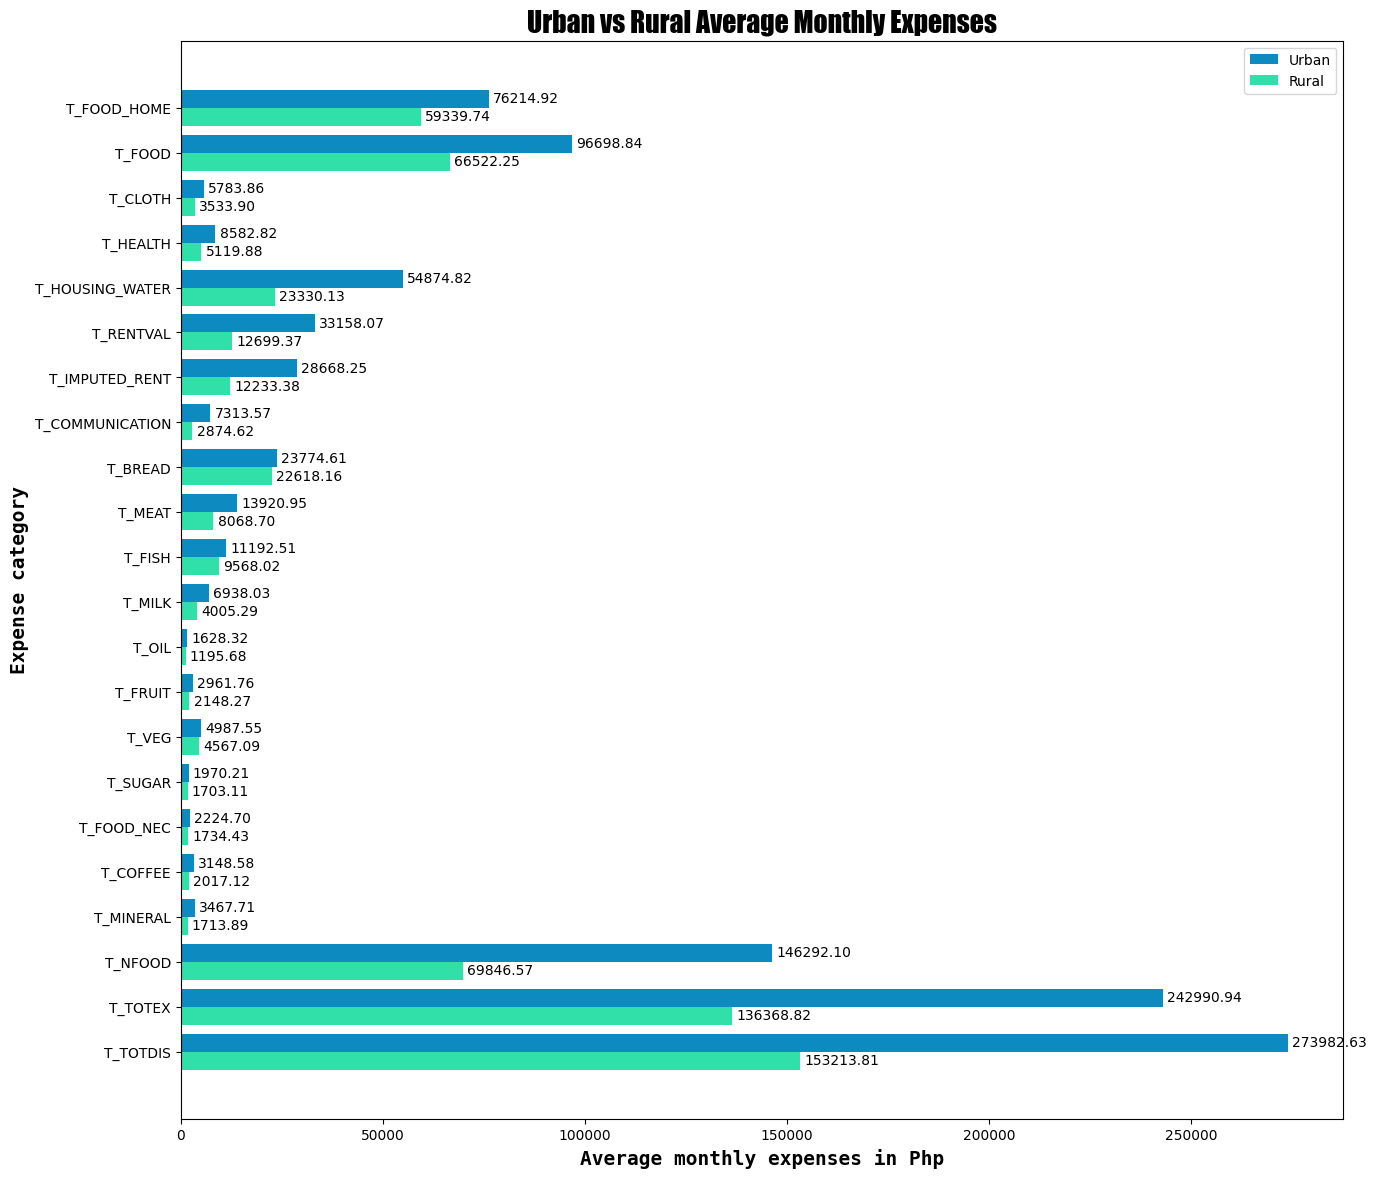

In [10]:
# Compare the average monthly expenses of urban and rural households
compareChart(
    mode="T", # expense
    n=len(T_columns), 
    cat=T_columns, 
    figwidth=15, 
    figheight=14, 
    urban_columns=urban_T_mean_sr.values, 
    rural_columns=rural_T_mean_sr.values, 
    title="Urban vs Rural Average Monthly Expenses"
)

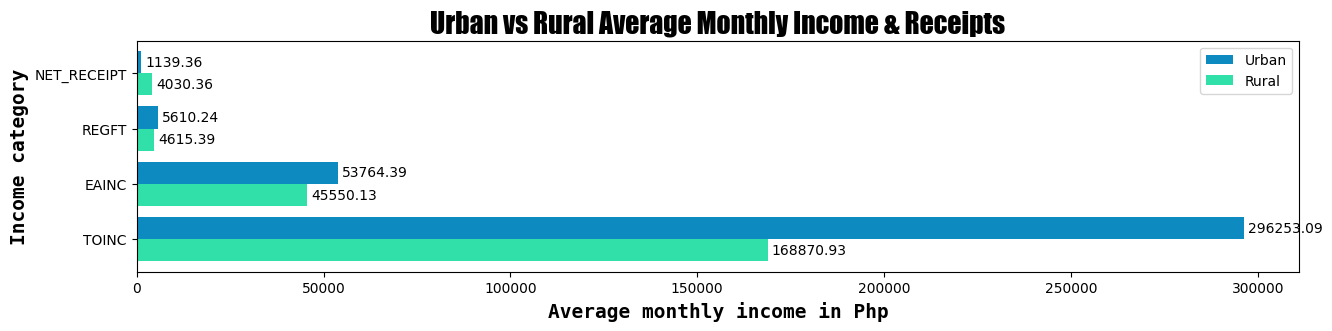

In [11]:
# Compare the average monthly income and receipts of urban and rural households
compareChart(
    mode="N", # income
    n=len(NET_columns), 
    cat=NET_columns, 
    figwidth=15, 
    figheight=3,
    urban_columns=urban_NET_mean_sr.values, 
    rural_columns=rural_NET_mean_sr.values, 
    title="Urban vs Rural Average Monthly Income & Receipts"
)

 ### **2.) Regional Distribution** 

In [12]:

# ── Label mappings ────────────────────────────────────────────────────────────
REGION_LABELS = {
    1:  "Region I\n(Ilocos)",         2:  "Region II\n(Cagayan Valley)",
    3:  "Region III\n(C. Luzon)",     5:  "Region V\n(Bicol)",
    6:  "Region VI\n(W. Visayas)",    7:  "Region VII\n(C. Visayas)",
    8:  "Region VIII\n(E. Visayas)",  9:  "Region IX\n(Zamboanga)",
    10: "Region X\n(N. Mindanao)",    11: "Region XI\n(Davao)",
    12: "Region XII\n(SOCCSKSARGEN)", 13: "NCR",
    14: "CAR",                        15: "ARMM",
    16: "CARAGA",                     41: "Region IVA\n(CALABARZON)",
    42: "Region IVB\n(MIMAROPA)",
}
BLDG_LABELS  = {1:"Single House", 2:"Duplex", 3:"Multi-unit", 4:"Commercial/Industrial", 5:"Makeshift", 6:"Other"}
ROOF_LABELS  = {1:"Strong", 2:"Light", 3:"Salvaged/Makeshift", 4:"Mixed→Strong", 5:"Mixed→Light", 6:"Mixed→Salvaged", 7:"N/A"}
WALLS_LABELS = {1:"Strong", 2:"Light", 3:"Salvaged/Makeshift", 4:"Mixed→Strong", 5:"Mixed→Light", 6:"Mixed→Salvaged", 7:"N/A"}
TOILET_LABELS= {0:"None", 1:"Water-sealed (own)", 2:"Water-sealed (shared)", 3:"WS Other (own)", 4:"WS Other (shared)", 5:"Closed Pit", 6:"Open Pit", 7:"Others"}
ELECTRIC_LABELS = {1:"Yes", 2:"No"}
WATER_LABELS = {
    1:"Comm. Faucet (own)", 2:"Comm. Faucet (shared)", 3:"Deep Well (own)",
    4:"Deep Well (shared)", 5:"Shallow Well", 6:"Dug Well",
    7:"Protected Spring", 8:"Unprotected Spring", 9:"Lake/River/Rain",
    10:"Peddler", 11:"Bottled", 12:"Others"
}

urban_c, rural_c = "#0d8ac0", "#30e0a8"

# Apply readable labels to a working copy
fies_subset_df_labeled = fies_subset_df.copy()
fies_subset_df_labeled["URB_LABEL"]   = fies_subset_df_labeled["URB"].map({1:"Urban", 2:"Rural"})
fies_subset_df_labeled["REGION_LABEL"]= fies_subset_df_labeled["W_REGN"].map(REGION_LABELS)


print("Label mappings ready.")


Label mappings ready.


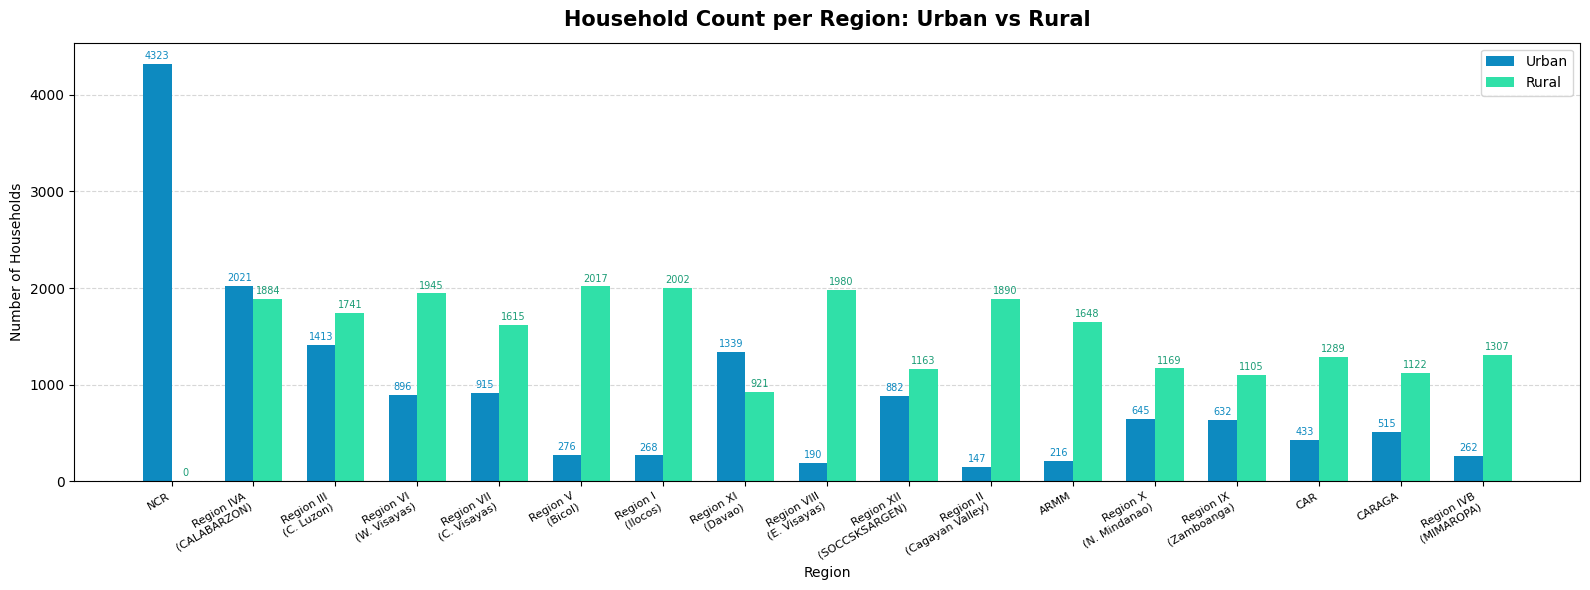

In [13]:

# ── Regional counts: Urban vs Rural ─────────────────────────────────────────
region_urb = (
    fies_subset_df_labeled
    .groupby(["REGION_LABEL", "URB_LABEL"])
    .size()
    .unstack(fill_value=0)
)

# Ensure both columns exist
for col in ["Urban", "Rural"]:
    if col not in region_urb.columns:
        region_urb[col] = 0

region_urb["Total"] = region_urb["Urban"] + region_urb["Rural"]
region_urb = region_urb.sort_values("Total", ascending=False)

# ── Plot 1: Grouped bar — raw counts ────────────────────────────────────────
regions = region_urb.index.tolist()
x       = np.arange(len(regions))
bar_w   = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
b_u = ax.bar(x - bar_w/2, region_urb["Urban"], bar_w, label="Urban", color=urban_c)
b_r = ax.bar(x + bar_w/2, region_urb["Rural"],  bar_w, label="Rural",  color=rural_c)

for bar in b_u:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=7, color=urban_c)
for bar in b_r:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=7, color="#1a9c75")

ax.set_title("Household Count per Region: Urban vs Rural", fontsize=15, fontweight="bold", pad=12)
ax.set_xticks(x); ax.set_xticklabels(regions, fontsize=8, rotation=30, ha="right")
ax.set_xlabel("Region"); ax.set_ylabel("Number of Households")
ax.yaxis.grid(True, linestyle="--", alpha=0.5); ax.set_axisbelow(True)
ax.legend()
plt.tight_layout(); plt.show()


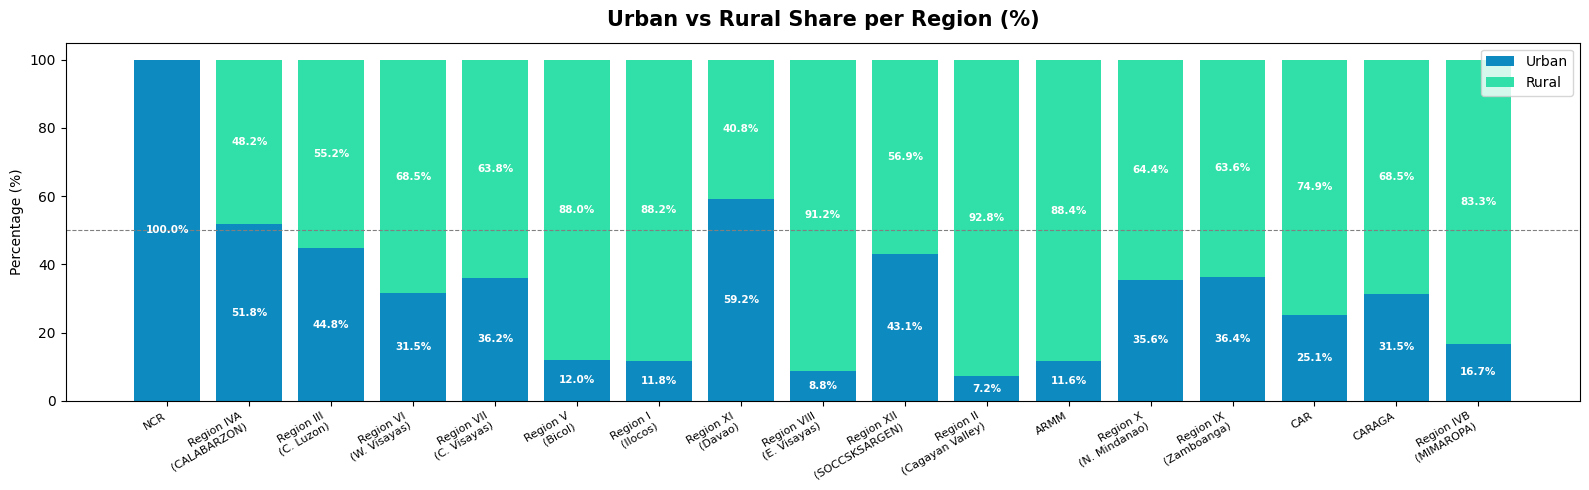


Region                             Urban   Rural   Total  %Urban  %Rural
────────────────────────────────────────────────────────────────────
NCR                                 4323       0    4323   100.0     0.0
Region IVA (CALABARZON)             2021    1884    3905    51.8    48.2
Region III (C. Luzon)               1413    1741    3154    44.8    55.2
Region VI (W. Visayas)               896    1945    2841    31.5    68.5
Region VII (C. Visayas)              915    1615    2530    36.2    63.8
Region V (Bicol)                     276    2017    2293    12.0    88.0
Region I (Ilocos)                    268    2002    2270    11.8    88.2
Region XI (Davao)                   1339     921    2260    59.2    40.8
Region VIII (E. Visayas)             190    1980    2170     8.8    91.2
Region XII (SOCCSKSARGEN)            882    1163    2045    43.1    56.9
Region II (Cagayan Valley)           147    1890    2037     7.2    92.8
ARMM                                 216    1648    18

In [14]:

# Plot 2: Stacked 100% bar — Urban/Rural proportion per region 
region_pct = region_urb[["Urban","Rural"]].div(region_urb["Total"], axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(regions, region_pct["Urban"], label="Urban", color=urban_c)
ax.bar(regions, region_pct["Rural"], bottom=region_pct["Urban"], label="Rural", color=rural_c)

for i, r in enumerate(regions):
    u, ru = region_pct.loc[r,"Urban"], region_pct.loc[r,"Rural"]
    if u  >= 6: ax.text(i, u/2,    f"{u:.1f}%",  ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")
    if ru >= 6: ax.text(i, u+ru/2, f"{ru:.1f}%", ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")

ax.axhline(50, linestyle="--", color="gray", linewidth=0.8)
ax.set_title("Urban vs Rural Share per Region (%)", fontsize=15, fontweight="bold", pad=12)
ax.set_xticks(range(len(regions))); ax.set_xticklabels(regions, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("Percentage (%)"); ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout(); plt.show()

# Summary table
stats = region_urb.copy()
stats["% Urban"] = (stats["Urban"] / stats["Total"] * 100).round(1)
stats["% Rural"] = (stats["Rural"] / stats["Total"] * 100).round(1)
print(f"\n{'Region':<32} {'Urban':>7} {'Rural':>7} {'Total':>7} {'%Urban':>7} {'%Rural':>7}")
print("─" * 68)
for region, row in stats.iterrows():
    print(f"{region.replace(chr(10),' '):<32} {int(row.Urban):>7} {int(row.Rural):>7} {int(row.Total):>7} {row['% Urban']:>7.1f} {row['% Rural']:>7.1f}")
print("─" * 68)
tot = stats[["Urban","Rural","Total"]].sum()
print(f"{'TOTAL':<32} {int(tot.Urban):>7} {int(tot.Rural):>7} {int(tot.Total):>7} {tot.Urban/tot.Total*100:>7.1f} {tot.Rural/tot.Total*100:>7.1f}")


#### Structural Feature Distributions: Urban vs Rural
How building type, roof material, and wall material differ between urban and rural households.

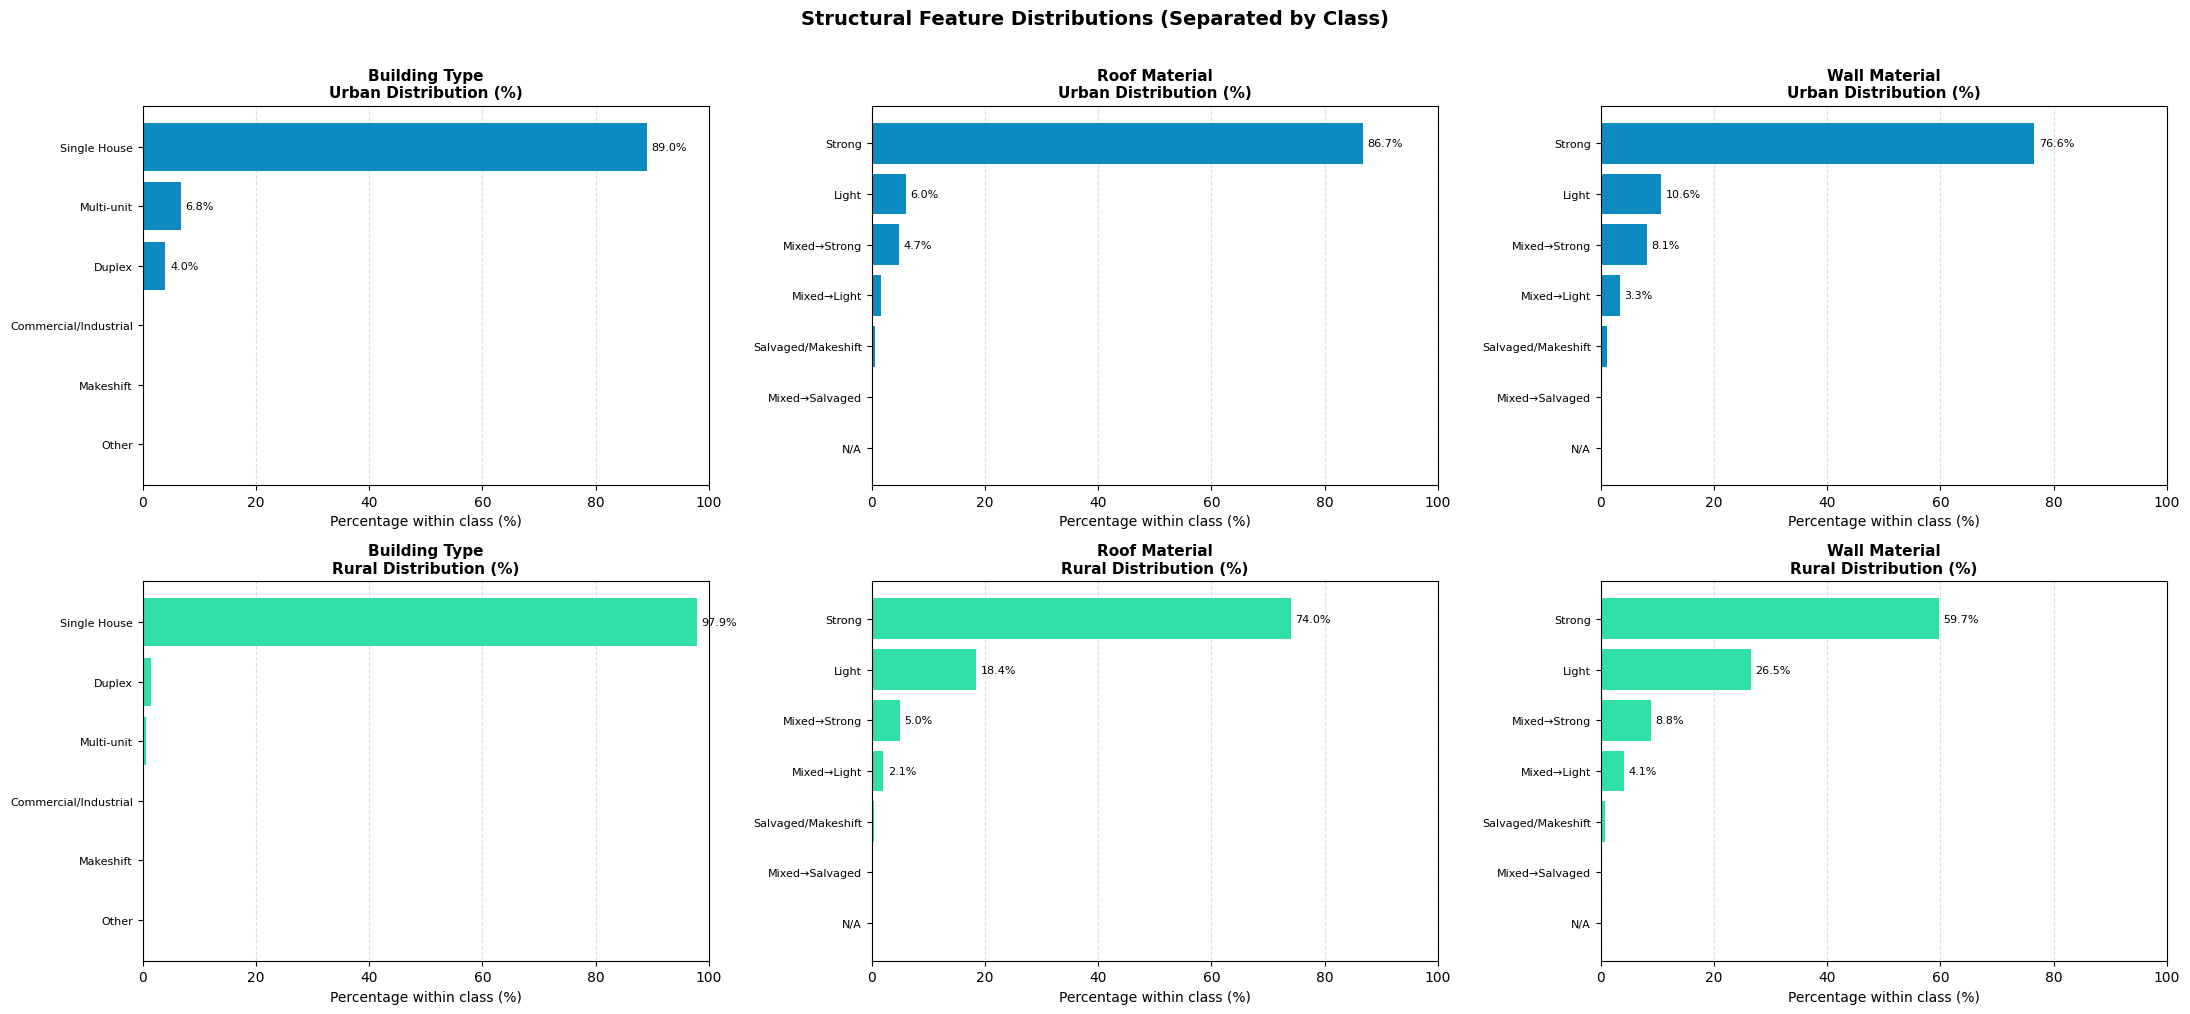

In [15]:

def stacked_pct_chart(ax, df, col, label_map, title, urb_col="URB_LABEL"):
    grouped = (
        df.groupby([col, urb_col])
        .size()
        .unstack(fill_value=0)
    )

    for c in ["Urban", "Rural"]:
        if c not in grouped:
            grouped[c] = 0

    grouped["Total"] = grouped["Urban"] + grouped["Rural"]
    grouped = grouped.sort_values("Total", ascending=True)
    grouped["Rural_prop"] = (grouped["Rural"] / sum(grouped["Rural"])) * 100
    grouped["Urban_prop"] = (grouped["Urban"] / sum(grouped["Urban"])) * 100
    grouped["Urban%"] = (grouped["Urban_prop"] / (grouped["Rural_prop"] + grouped["Urban_prop"])) * 100
    grouped["Rural%"] = (grouped["Rural_prop"] / (grouped["Rural_prop"] + grouped["Urban_prop"])) * 100

    labels = [label_map.get(idx, str(idx)) for idx in grouped.index]
    y = np.arange(len(labels))

    ax.barh(y, grouped["Urban%"], color=urban_c, label="Urban")
    ax.barh(y, grouped["Rural%"], left=grouped["Urban%"], color=rural_c, label="Rural")

    for i in range(len(y)):
        u, r = grouped["Urban%"].iloc[i], grouped["Rural%"].iloc[i]
        if u >= 8:
            ax.text(u / 2, i, f"{u:.1f}%", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        if r >= 8:
            ax.text(u + r / 2, i, f"{r:.1f}%", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

    ax.axvline(50, color="gray", linestyle="--", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Percentage (%)")
    ax.set_title(title, fontsize=12, fontweight="bold")


fig, axes = plt.subplots(2, 3, figsize=(22, 10), sharex=False)


plot_single_class_distribution(
    axes[0, 0], fies_subset_df_labeled, "BLDG_TYPE", BLDG_LABELS,
    class_label="Urban", color=urban_c,
    title="Building Type\nUrban Distribution (%)"
 )
plot_single_class_distribution(
    axes[0, 1], fies_subset_df_labeled, "ROOF", ROOF_LABELS,
    class_label="Urban", color=urban_c,
    title="Roof Material\nUrban Distribution (%)"
 )
plot_single_class_distribution(
    axes[0, 2], fies_subset_df_labeled, "WALLS", WALLS_LABELS,
    class_label="Urban", color=urban_c,
    title="Wall Material\nUrban Distribution (%)"
 )

plot_single_class_distribution(
    axes[1, 0], fies_subset_df_labeled, "BLDG_TYPE", BLDG_LABELS,
    class_label="Rural", color=rural_c,
    title="Building Type\nRural Distribution (%)"
 )
plot_single_class_distribution(
    axes[1, 1], fies_subset_df_labeled, "ROOF", ROOF_LABELS,
    class_label="Rural", color=rural_c,
    title="Roof Material\nRural Distribution (%)"
 )
plot_single_class_distribution(
    axes[1, 2], fies_subset_df_labeled, "WALLS", WALLS_LABELS,
    class_label="Rural", color=rural_c,
    title="Wall Material\nRural Distribution (%)"
 )

fig.suptitle(
    "Structural Feature Distributions (Separated by Class)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()


#### Amenity Distributions: Urban vs Rural
Toilet type, electricity access, and water source.

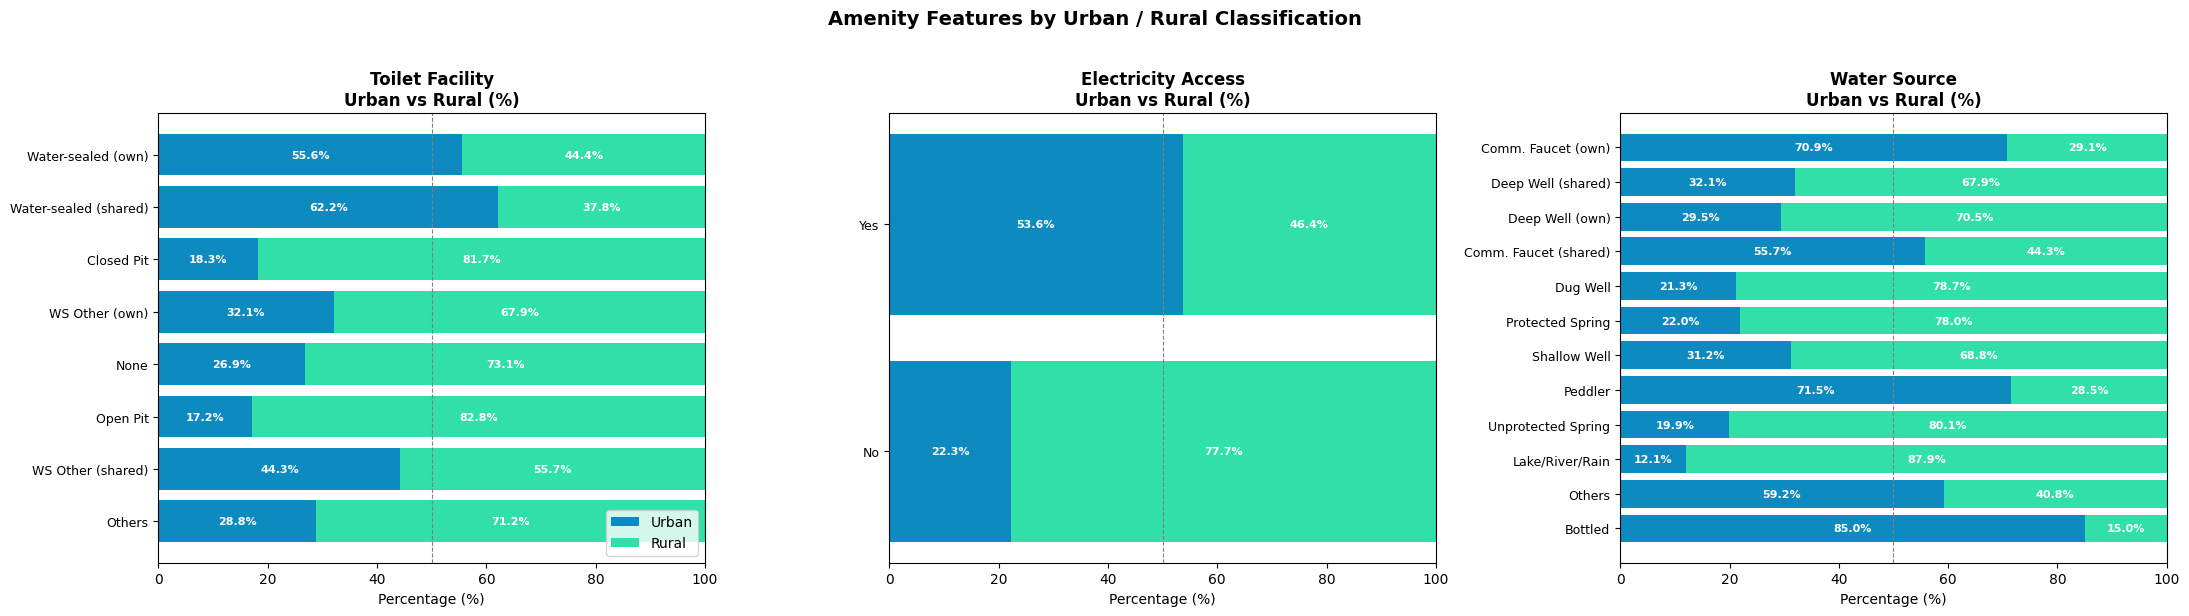

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(24, 11), sharex=False)

plot_single_class_distribution(
    axes[0, 0], fies_subset_df_labeled, "TOILET", TOILET_LABELS,
    class_label="Urban", color=urban_c,
    title="Toilet Facility\nUrban Distribution (%)"
 )
plot_single_class_distribution(
    axes[0, 1], fies_subset_df_labeled, "ELECTRIC", ELECTRIC_LABELS,
    class_label="Urban", color=urban_c,
    title="Electricity Access\nUrban Distribution (%)"
 )
plot_single_class_distribution(
    axes[0, 2], fies_subset_df_labeled, "WATER", WATER_LABELS,
    class_label="Urban", color=urban_c,
    title="Water Source\nUrban Distribution (%)"
 )

plot_single_class_distribution(
    axes[1, 0], fies_subset_df_labeled, "TOILET", TOILET_LABELS,
    class_label="Rural", color=rural_c,
    title="Toilet Facility\nRural Distribution (%)"
 )
plot_single_class_distribution(
    axes[1, 1], fies_subset_df_labeled, "ELECTRIC", ELECTRIC_LABELS,
    class_label="Rural", color=rural_c,
    title="Electricity Access\nRural Distribution (%)"
 )
plot_single_class_distribution(
    axes[1, 2], fies_subset_df_labeled, "WATER", WATER_LABELS,
    class_label="Rural", color=rural_c,
    title="Water Source\nRural Distribution (%)"
 )

fig.suptitle(
    "Amenity Feature Distributions (Separated by Class)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()


#### Appliance & Vehicle Ownership: Urban vs Rural
Average ownership counts per household for appliances and vehicles.

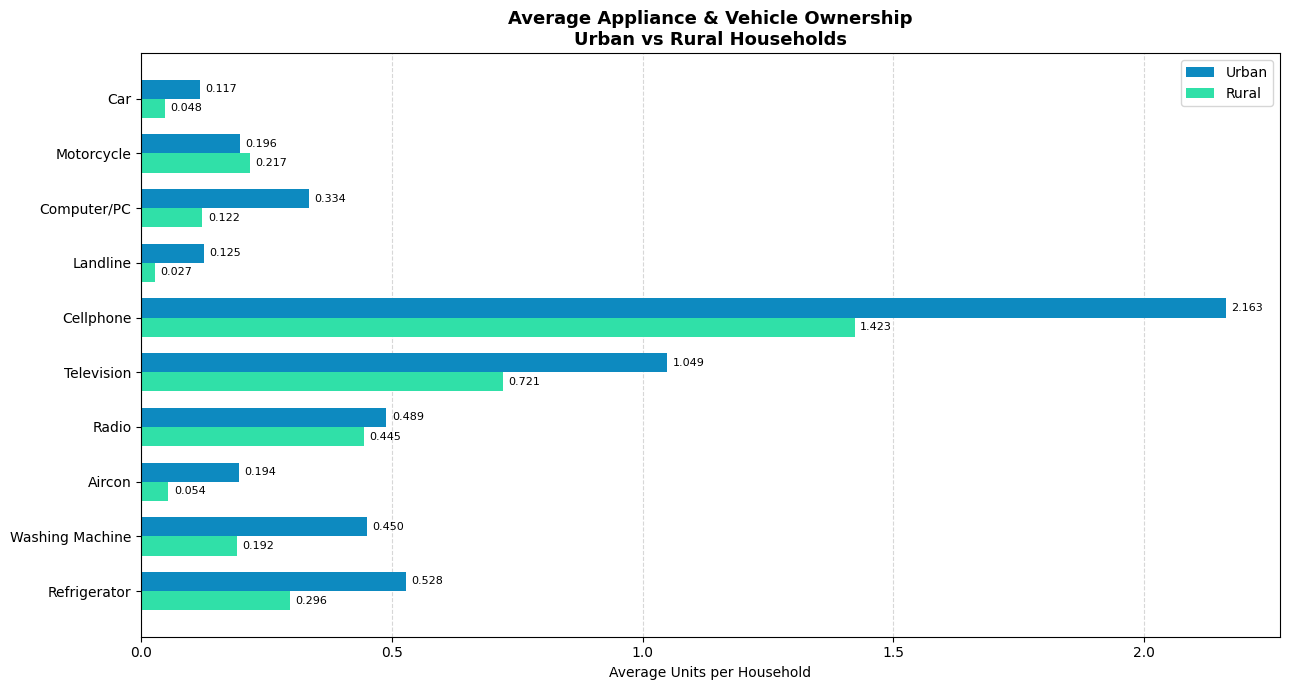

In [17]:

appliance_cols = {
    "CAR_QTY":        "Car",
    "MOTORCYCLE_QTY": "Motorcycle",
    "PC_QTY":         "Computer/PC",
    "LANDLINE_QTY":   "Landline",
    "CELLPHONE_QTY":  "Cellphone",
    "TV_QTY":         "Television",
    "RADIO_QTY":      "Radio",
    "AIRCON_QTY":     "Aircon",
    "WASH_QTY":       "Washing Machine",
    "REF_QTY":        "Refrigerator",
}

app_df = fies_subset_df_labeled[list(appliance_cols.keys()) + ["URB_LABEL"]].copy()
for col in appliance_cols:
    app_df[col] = pd.to_numeric(app_df[col], errors="coerce")

app_mean = (
    app_df
    .groupby("URB_LABEL")[list(appliance_cols.keys())]
    .mean()
    .rename(columns=appliance_cols)
    .T
)

n = len(app_mean)
y = np.arange(n)
bar_h = 0.35

fig, ax = plt.subplots(figsize=(13, 7))
b_u = ax.barh(y - bar_h/2, app_mean["Urban"], height=bar_h, label="Urban", color=urban_c)
b_r = ax.barh(y + bar_h/2, app_mean["Rural"],  height=bar_h, label="Rural",  color=rural_c)

ax.bar_label(b_u, padding=4, fmt="{:.3f}", fontsize=8)
ax.bar_label(b_r, padding=4, fmt="{:.3f}", fontsize=8)

ax.set_yticks(y); ax.set_yticklabels(app_mean.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Average Units per Household")
ax.set_title("Average Appliance & Vehicle Ownership\nUrban vs Rural Households",
             fontsize=13, fontweight="bold")
ax.xaxis.grid(True, linestyle="--", alpha=0.5); ax.set_axisbelow(True)
ax.legend()
plt.tight_layout(); plt.show()


 ### **3.) Household Composition** 

Household Physical Composition (BLDG_TYPE, ROOF, WALLS, TOILET, ELECTRIC, WATER)

In [18]:
physical_features = ['BLDG_TYPE', 'ROOF', 'WALLS', 'TOILET', 'ELECTRIC', 'WATER']

# A. Statistical summaries
print("Physical Housing Composition Summaries")
for col in physical_features:
    if col in ws_or_na_df.columns:
        print(f"\nValue Counts for {col}:")
        print(ws_or_na_df[col].value_counts(normalize=True) * 100)

Physical Housing Composition Summaries

Value Counts for BLDG_TYPE:
BLDG_TYPE
1    94.503498
3     2.957357
2     2.392273
4     0.109532
5     0.027383
6     0.009957
Name: proportion, dtype: float64

Value Counts for ROOF:
ROOF
1    78.867840
2    13.698937
4     4.889099
5     1.924274
3     0.465510
6     0.144383
7     0.009957
Name: proportion, dtype: float64

Value Counts for WALLS:
WALLS
1    66.172114
2    20.407757
4     8.543477
5     3.778845
3     0.831446
6     0.253915
7     0.012447
Name: proportion, dtype: float64

Value Counts for TOILET:
TOILET
1    67.797665
2     8.466307
5     6.118842
3     5.588609
0     4.799482
6     3.689229
4     2.397252
7     1.142615
Name: proportion, dtype: float64

Value Counts for ELECTRIC:
ELECTRIC
1    86.843743
2    13.156257
Name: proportion, dtype: float64

Value Counts for WATER:
WATER
1     37.868114
4     16.118593
3     11.963855
2     11.030345
6      8.643051
7      5.060865
5      3.519952
10     2.068656
8      1.824699
9 

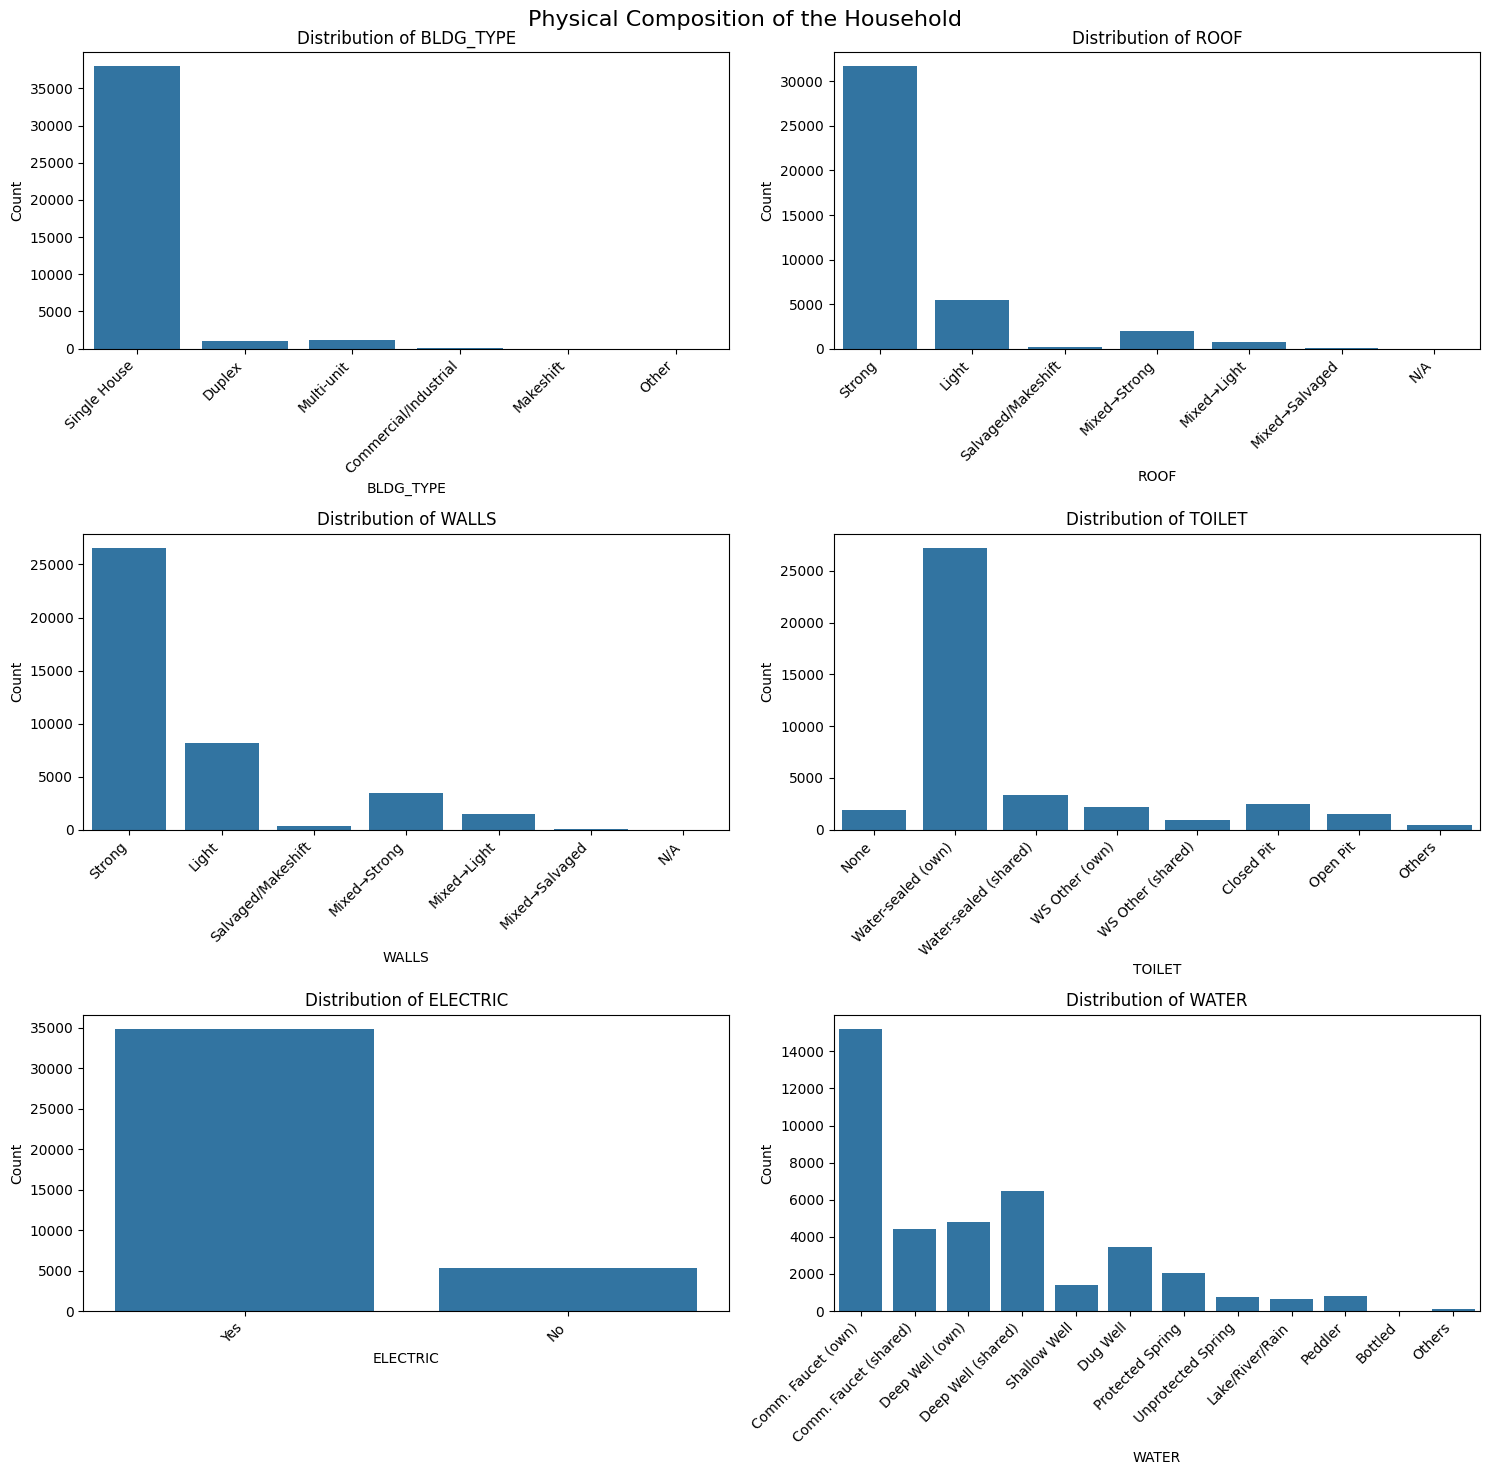

In [19]:
# B. Visualizing Physical Housing Composition (Categorical)
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('Physical Composition of the Household', fontsize=16)

def set_xtick_labels(labels):
    ax.set_xticks([float(x) for x in range(0, len(labels))])
    ax.set_xticklabels(list(labels.values()), rotation=45, ha='right')

for i, col in enumerate(physical_features):
    if col in ws_or_na_df.columns:
        ax = axes[i//2, i%2]
        sns.countplot(data=ws_or_na_df, x=col, ax=ax)
        ax.set_title(f'Distribution of {col}')
        ax.tick_params(axis='x', rotation=45) 
        ax.set_ylabel('Count')

        if col=="BLDG_TYPE":
            set_xtick_labels(BLDG_LABELS)
        if col=="ROOF":
            set_xtick_labels(ROOF_LABELS)
        if col=="WALLS":
            set_xtick_labels(WALLS_LABELS)
        if col=="TOILET":
            set_xtick_labels(TOILET_LABELS)
        if col=="ELECTRIC":
            set_xtick_labels(ELECTRIC_LABELS)
        if col=="WATER":
            set_xtick_labels(WATER_LABELS)
        
plt.tight_layout()
plt.show()

Household Asset Composition

In [20]:
asset_features = ['CAR_QTY', 'MOTORCYCLE_QTY', 'PC_QTY', 'LANDLINE_QTY', 'CELLPHONE_QTY', 
                  'TV_QTY', 'RADIO_QTY', 'AIRCON_QTY', 'WASH_QTY', 'REF_QTY']

# A. Statistical summaries
print("\nHousehold Asset Composition Summaries")
display(ws_or_na_df[asset_features].describe())


Household Asset Composition Summaries


,CAR_QTY,MOTORCYCLE_QTY,PC_QTY,LANDLINE_QTY,CELLPHONE_QTY,TV_QTY,RADIO_QTY,AIRCON_QTY,WASH_QTY,REF_QTY
count,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000
mean,0.074332,0.209081,0.203306,0.064499,1.706082,0.846432,0.461701,0.107764,0.290682,0.384979
std,0.326798,0.487354,0.537806,0.279669,1.543661,0.654158,0.535887,0.410240,0.467002,0.535224
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,6.000000,11.000000,6.000000,5.000000,14.000000,7.000000,5.000000,8.000000,6.000000,5.000000


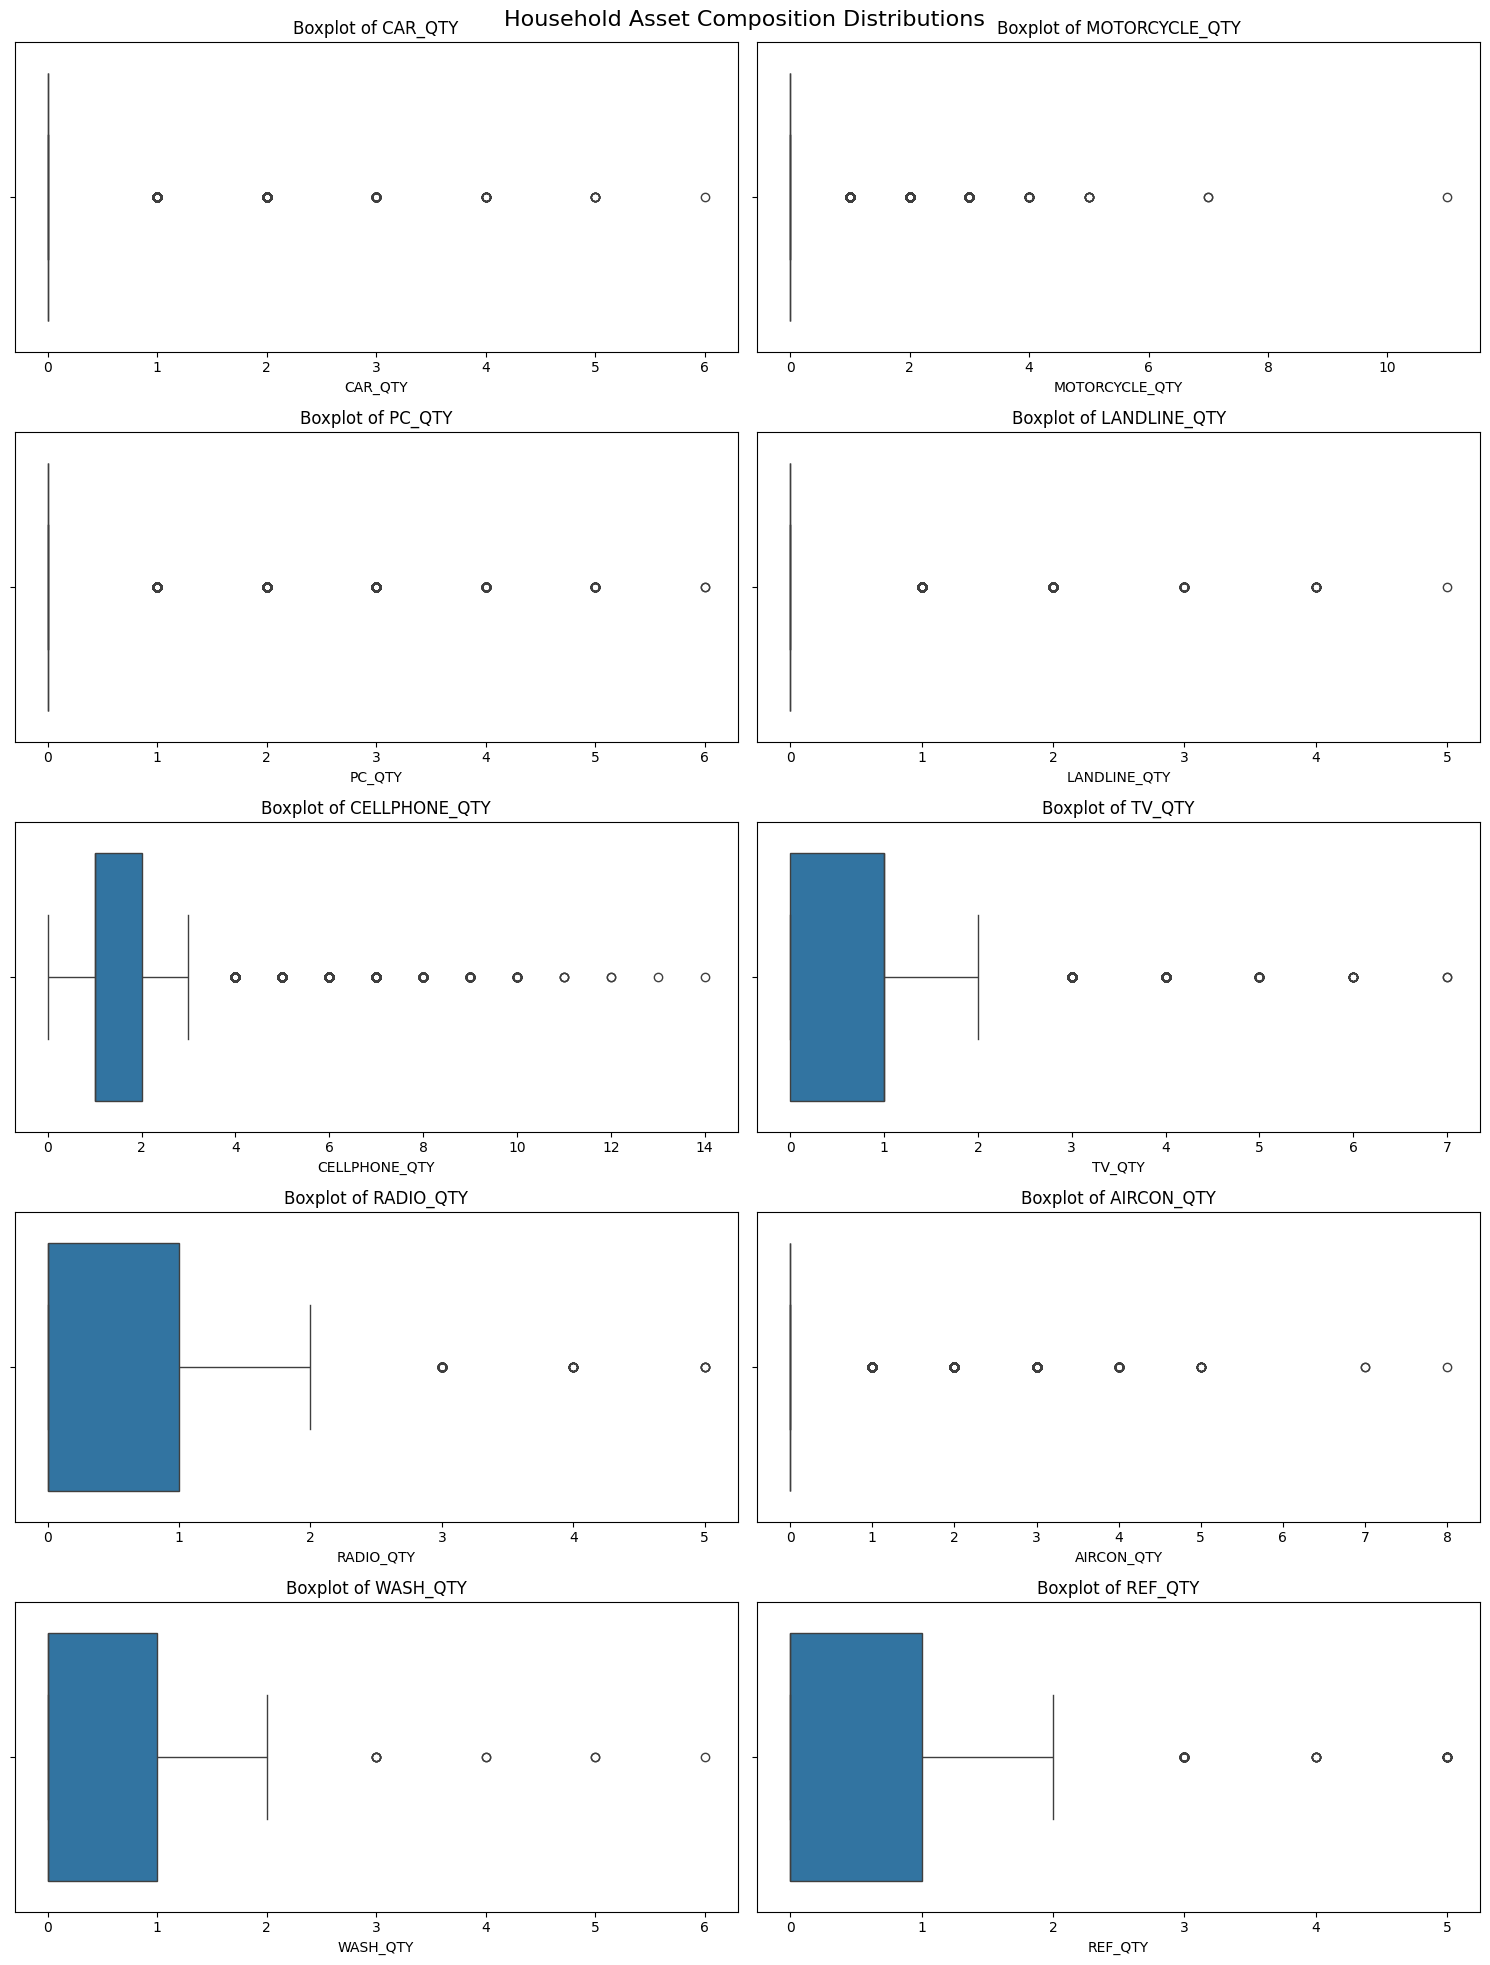

In [21]:
# B. Visualizing Asset/Appliance Quantities (Numerical)
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
fig.suptitle('Household Asset Composition Distributions', fontsize=16)

for i, col in enumerate(asset_features):
    if col in ws_or_na_df.columns:
        ax = axes[i//2, i%2]

        # Using a boxplot to easily spot outliers
        sns.boxplot(data=ws_or_na_df, x=col, ax=ax)
        ax.set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

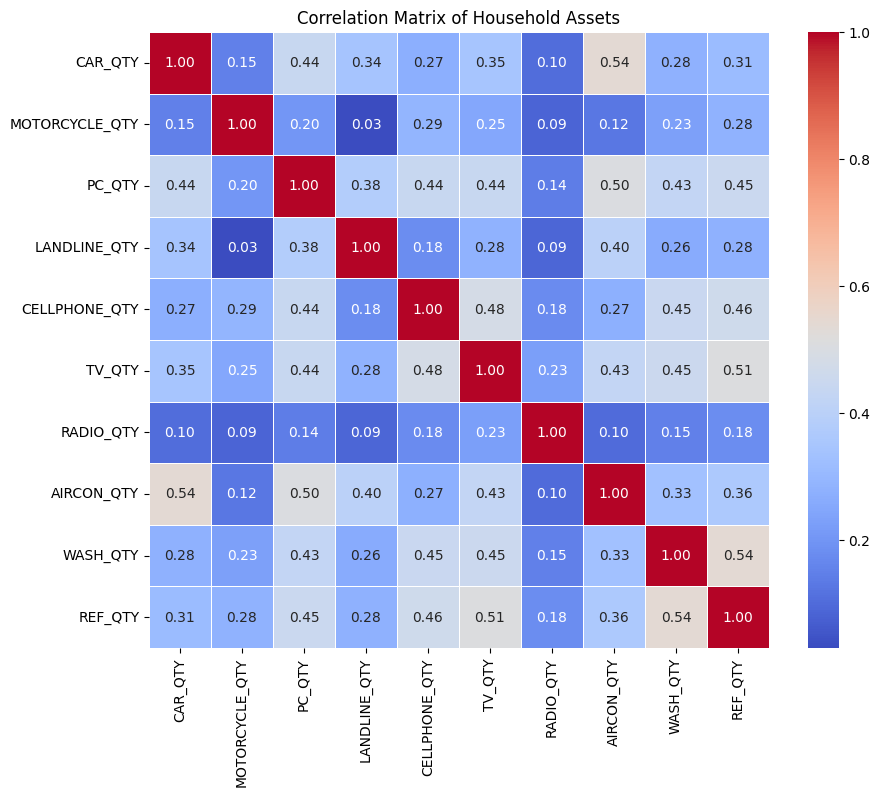

In [22]:
# C. Asset Correlation Heatmap 
# To see if owning certain items correlates with owning others
plt.figure(figsize=(10, 8))

# Coercing errors to NaN due to non-numeric entries (should we move this earlier?)
df_assets_numeric = ws_or_na_df[asset_features].apply(pd.to_numeric, errors='coerce')

correlation_matrix = df_assets_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Household Assets')
plt.show()

# **[3]** Data Preprocessing
In this phase, we will prepare our dataset for the machine learning models. This involves converting our target variable to a standard binary format, testing and handling of outliers, handling nominal categorical variables through One-Hot Encoding, splitting the data into training, validation, and test sets to prevent data leakage, and standardizing our numerical features.

### 1. Target Variable Encoding
Currently, our target variable `URB` is encoded as `1` for Urban and `2` for Rural. Supervised machine learning algorithms generally expect binary classification targets to be represented as `0` and `1`. We will remap the Rural category from `2` to `0`.

In [23]:
# Map URB: 1 remains 1 (Urban), 2 becomes 0 (Rural)
fies_subset_df['URB'] = fies_subset_df['URB'].replace(2, 0)

# Verify the changes
print("Target Variable Distribution (1 = Urban, 0 = Rural):")
print(fies_subset_df['URB'].value_counts())

Target Variable Distribution (1 = Urban, 0 = Rural):
URB
0    24798
1    15373
Name: count, dtype: int64


### 2. Train-Validation-Test Split
To avoid data leakage, we must ensure proper training-validation-test splits.
* **Training Set (70%):** Used to train our classical models and neural network.
* **Validation Set (15%):** Used to tune hyperparameters and evaluate the models during training.
* **Test Set (15%):** Used for the final, unbiased evaluation of our models.

We will use the `stratify` parameter to ensure the proportion of Urban and Rural households remains perfectly balanced across all three splits.

In [24]:
# Separate Features (X) and Target (y)
X = fies_subset_df.drop('URB', axis=1)
y = fies_subset_df['URB']

# First split: 70% Train, 30% Temporary (which will become Val and Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: Divide the 30% Temporary set equally into 15% Validation and 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 28119 samples
Validation set: 6026 samples
Testing set: 6026 samples


### 3. Feature Selection
To reduce noise and prevent overfitting, we evaluate the statistical significance of our features. To strictly prevent data leakage, all statistical tests (T-tests, Chi-Square, and Mutual Information) are calculated using **only the Training Set (`X_train` and `y_train`)**. The validation and test sets are kept entirely blind during this decision-making process. 

First, we will perform **T-tests** to compare the means of our numerical features between urban and rural households. If a numerical feature is found to be not significantly different between classes, then it may not be useful in training the machine learning models to distinguish them, and must therefore be dropped.

In [25]:
from scipy.stats import ttest_ind

t_test_results = {}

# List of categorical features to avoid performing t-tests on (since t-tests are for numerical data)
categorical_features = ['W_REGN', 'BLDG_TYPE', 'ROOF', 'WALLS', 'TOILET', 'ELECTRIC', 'WATER']

# Skip categorical features and only perform t-tests on numerical features
for col in X_train.columns: 
    if col not in categorical_features:
        # Filter using y_train, extract the column from X_train
        urban_values = X_train[y_train == 1][col].dropna()
        rural_values = X_train[y_train == 0][col].dropna() 
        
        if len(urban_values) > 1 and len(rural_values) > 1: 
            stat, p_value = ttest_ind(urban_values, rural_values, equal_var=False)
            t_test_results[col] = (stat, p_value)
        else:
            print(f"{col}: Not enough data for t-test")

t_test_results_df = pd.DataFrame.from_dict(t_test_results, orient='index', columns=['t_statistic', 'p_value'])
t_test_results_df['significant'] = t_test_results_df['p_value'] < 0.05

t_test_results_df

,t_statistic,p_value,significant
NET_RECEIPT,-62.731208,0.000000e+00,True
REGFT,3.685075,2.292846e-04,True
EAINC,4.273423,1.936027e-05,True
TOINC,38.816480,0.000000e+00,True
T_FOOD_HOME,37.153171,1.250378e-291,True
T_FOOD,48.550793,0.000000e+00,True
T_CLOTH,24.570944,7.495632e-131,True
T_HEALTH,9.302514,1.533024e-20,True
T_HOUSING_WATER,49.894550,0.000000e+00,True
T_RENTVAL,43.352495,0.000000e+00,True


Next, because our target variable (`URB`) is categorical, we will use the **Chi-Squared test for independence** to evaluate the statistical significance of the categorical features (e.g., Roof Type, Water Source) in our training data. Features found to be independent of the target variable will also need to be dropped.

In [26]:
from scipy.stats import chi2_contingency

chi2_results = {}

for col in categorical_features:
    if col in X_train.columns:
        # Crosstab uses y_train against the categorical column in X_train
        contingency_table = pd.crosstab(y_train, X_train[col])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        chi2_results[col] = (chi2, p)

chi2_results_df = pd.DataFrame.from_dict(chi2_results, orient='index', columns=['chi2_statistic', 'p_value'])
chi2_results_df['significant'] = chi2_results_df['p_value'] < 0.05

chi2_results_df

,chi2_statistic,p_value,significant
W_REGN,8231.611323,0.000000e+00,True
BLDG_TYPE,1197.084082,1.257732e-256,True
ROOF,896.516296,2.127767e-190,True
WALLS,1132.510652,1.927370e-241,True
TOILET,1667.109488,0.000000e+00,True
ELECTRIC,976.450080,2.361732e-214,True
WATER,4691.914580,0.000000e+00,True


Although features may be considered significant in the T-tests and Chi-Squared tests, these methods only capture simple, isolated relationships and were only used for initial screening. Thus, we follow up with computing the **Mutual Information (MI)** scores, which can measure the overall dependency between each feature and the target variable. A value of zero indicates independence, and higher scores indicate greater dependency.

https://www.blog.trainindata.com/mutual-information-with-python/  
https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_classif.html

We will plot these scores to visually identify an "elbow", a threshold where the predictive power of the remaining features becomes negligible.

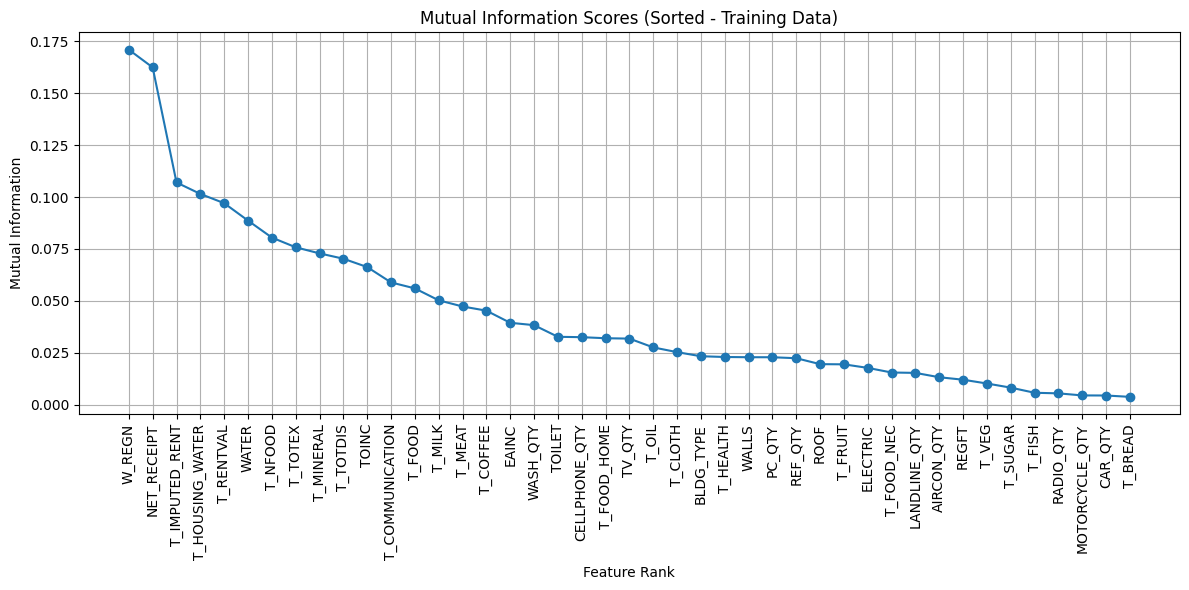

In [27]:
from sklearn.feature_selection import mutual_info_classif

# Compute mutual information scores
mi_scores = mutual_info_classif(X_train.fillna(0), y_train, random_state=0)
mi_scores_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

# Sort scores from highest to lowest
mi_sorted = mi_scores_series.sort_values(ascending=False)

# Graph MI score for each feature, from most to least significant in an attempt to find an "elbow"
plt.figure(figsize=(12, 6))
plt.plot(range(len(mi_sorted)), mi_sorted.values, marker='o')
plt.title("Mutual Information Scores (Sorted - Training Data)")
plt.xlabel("Feature Rank")
plt.ylabel("Mutual Information")
plt.xticks(range(len(mi_sorted)), mi_sorted.index, rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

Based on the Mutual Information graph generated from our training data, we have set a dropping threshold of `0.005`. 

To prevent a shape mismatch error during Model Training, the features identified as irrelevant must be removed across the board. We will now drop these specific columns from the Training, Validation, and Test sets simultaneously.

In [28]:
# Features with MI less than this will be dropped
threshold_for_dropping = 0.005

# Determine features to drop
features_to_drop = mi_scores_series[mi_scores_series < threshold_for_dropping].index

# Drop these features from Train, Validation, AND Test sets
X_train = X_train.drop(columns=features_to_drop)
X_val = X_val.drop(columns=features_to_drop)
X_test = X_test.drop(columns=features_to_drop)

print(f"Dropped {len(features_to_drop)} features.")
print(f"Remaining features for modeling: {X_train.shape[1]}")

Dropped 3 features.
Remaining features for modeling: 40


### 4. Handling Extreme Outliers (Log Transformation)
Financial features such as income (`Toinc`) and total expenditures (`T_TOTEX`) are highly right-skewed, meaning a small number of extremely wealthy households act as massive outliers. These extreme values can prevent our classical models and neural networks from learning effectively. 

To determine if our continuous financial features require transformation before modeling, we will visualize the distribution of Total Income (`TOINC`) and Total Expenditures (`T_TOTEX`).

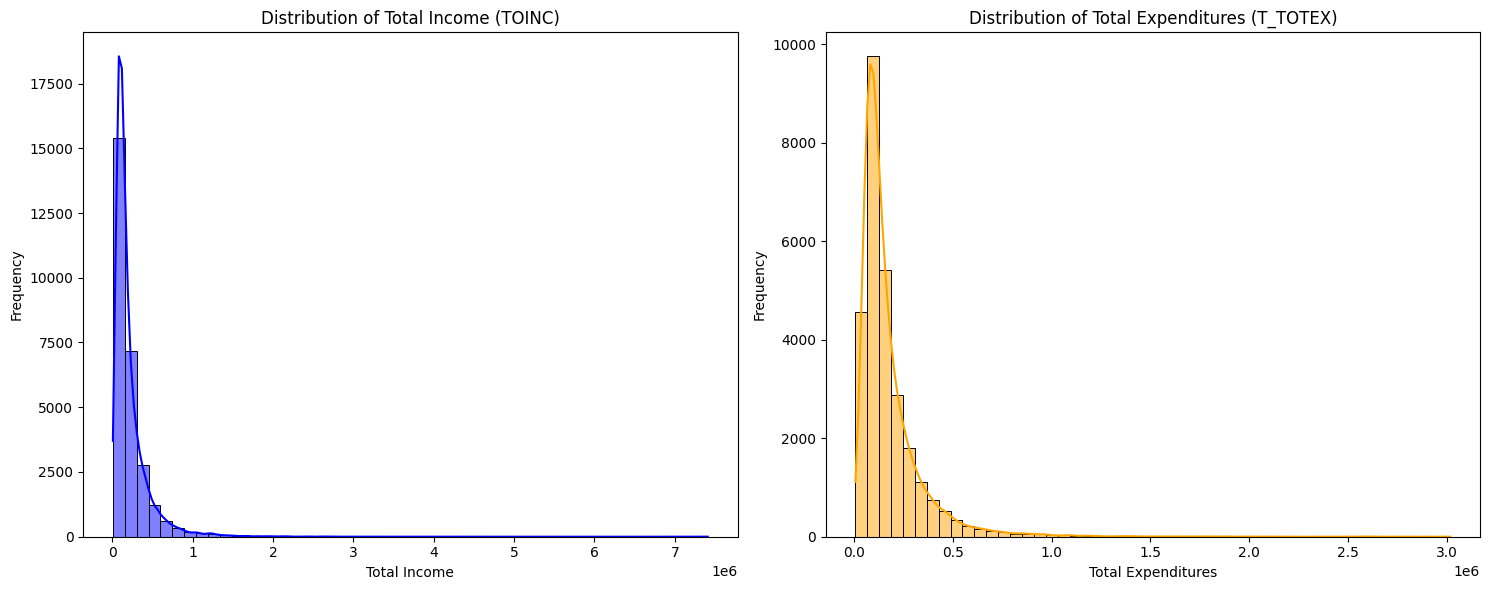

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Safely check if the columns survived feature selection before plotting
if 'TOINC' in X_train.columns:
    sns.histplot(X_train['TOINC'], bins=50, kde=True, ax=axes[0], color='blue')
    axes[0].set_title('Distribution of Total Income (TOINC)')
    axes[0].set_xlabel('Total Income')
    axes[0].set_ylabel('Frequency')

if 'T_TOTEX' in X_train.columns:
    sns.histplot(X_train['T_TOTEX'], bins=50, kde=True, ax=axes[1], color='orange')
    axes[1].set_title('Distribution of Total Expenditures (T_TOTEX)')
    axes[1].set_xlabel('Total Expenditures')
    axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Instead of dropping these valid data points, we will apply a Logarithmic Transformation (`np.log1p`) to all financial columns. This mathematical transformation pulls extreme values closer to the median, creating a more normalized, "bell-shaped" distribution that machine learning algorithms handle much better. We use `log1p` (which calculates $log(1+x)$) to avoid errors when taking the log of a feature with a value of exactly 0.

In [30]:
# Isolate the financial columns (Income and Expenditures)
# We exclude 'TOILET' just in case the string matcher accidentally catches it
financial_cols = [
    col for col in X_train.columns 
    if col.startswith(('T_', 'NET_', 'REGFT', 'EAINC', 'TOINC')) and col != 'TOILET'
]

# Apply log1p transformation to ALL THREE datasets
for col in financial_cols:
    X_train[col] = np.log1p(X_train[col])
    X_val[col] = np.log1p(X_val[col])
    X_test[col] = np.log1p(X_test[col])

Now let us check the new distribution and determine if Total Income (`TOINC`) and Total Expenditures (`T_TOTEX`) are still skewed.

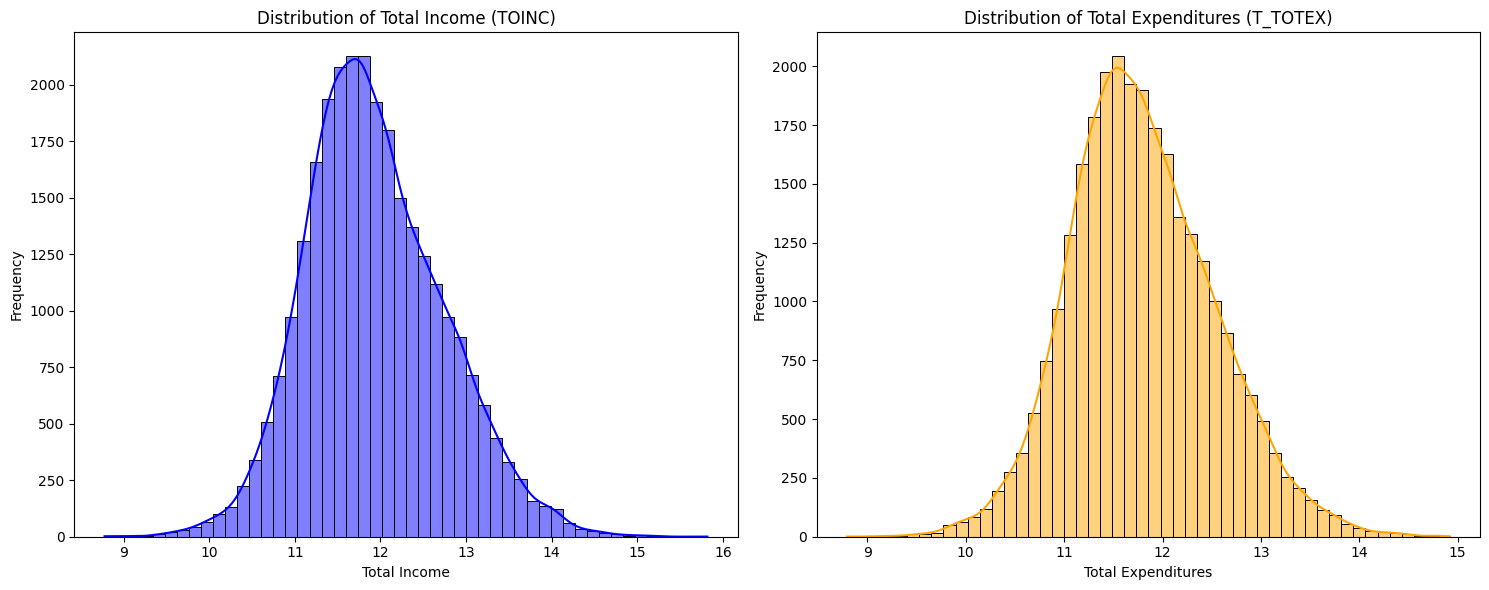

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Safely check if the columns survived feature selection before plotting
if 'TOINC' in X_train.columns:
    sns.histplot(X_train['TOINC'], bins=50, kde=True, ax=axes[0], color='blue')
    axes[0].set_title('Distribution of Total Income (TOINC)')
    axes[0].set_xlabel('Total Income')
    axes[0].set_ylabel('Frequency')

if 'T_TOTEX' in X_train.columns:
    sns.histplot(X_train['T_TOTEX'], bins=50, kde=True, ax=axes[1], color='orange')
    axes[1].set_title('Distribution of Total Expenditures (T_TOTEX)')
    axes[1].set_xlabel('Total Expenditures')
    axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 5. One-Hot Encoding Categorical Features
Our dataset contains several nominal categorical features: `W_REGN`, `BLDG_TYPE`, `ROOF`, `WALLS`, `TOILET`, `ELECTRIC`, and `WATER`. Leaving these as arbitrary numbers might cause algorithms to incorrectly assume they have a mathematical hierarchy (e.g., Region 5 is "greater" than Region 2). 

To fix this, we apply One-Hot Encoding to convert them into binary indicator variables. We also use `drop_first=True` to drop the first category of each feature. This prevents multicollinearity (the "dummy variable trap"), which is highly beneficial for classical machine learning models like Logistic Regression.

In [32]:
# Define categorical columns
categorical_cols = ['W_REGN', 'BLDG_TYPE', 'ROOF', 'WALLS', 'TOILET', 'ELECTRIC', 'WATER']

# Ensure that we only encode columns that are still present after feature selection
cols_to_encode = [col for col in categorical_cols if col in X_train.columns]

# Check the old shape of the dataset
print(f"Original subset shape: {X_train.shape}")

X_train = pd.get_dummies(X_train, columns=cols_to_encode, drop_first=True)
X_val = pd.get_dummies(X_val, columns=cols_to_encode, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_to_encode, drop_first=True)

# Align columns in case some categories only existed in the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Check the new shape of the dataset
print(f"Encoded dataset shape: {X_train.shape}")

Original subset shape: (28119, 40)
Encoded dataset shape: (28119, 85)


### 6. Feature Scaling (Using RobustScaler)
Our features operate on vastly different scales. While our financial features have been log-transformed, our asset counts (like `CAR_QTY`) still range from 0 to 5, and our One-Hot Encoded variables are binary (0 or 1). 

Machine learning algorithms—especially Neural Networks and distance-based classical models—require features to be on a similar scale to converge properly. Because we still have some lingering outliers even after the log transformation, we will use `RobustScaler` instead of `StandardScaler`. `RobustScaler` scales the data using the median and the Interquartile Range (IQR), making it completely immune to extreme outliers.

**Important Data Leakage Prevention:** The scaler must be fitted *only* on the training data. We then apply that learned transformation to the validation and test sets.

In [33]:
# Initialize the RobustScaler
scaler = RobustScaler()

# Fit the scaler ONLY on the training data, then transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the validation and test sets using the previously fitted scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames to retain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)

To ensure strict consistency across all our machine learning models and to prevent accidental data leakage, we have centralized our data preprocessing in this notebook. 

Below, we export our final, robustly scaled training, validation, and test sets using the `joblib` library. Our individual model notebooks (Random Forest, Logistic Regression, Gradient Boosting, and MLP) will load these exact files. This guarantees that every algorithm in our project is trained, tuned, and evaluated on the exact same data splits.

In [34]:
import joblib
import os

os.makedirs('processed_data', exist_ok=True)

# Export the feature sets
joblib.dump(X_train_scaled, 'processed_data/X_train_scaled.pkl')
joblib.dump(X_val_scaled, 'processed_data/X_val_scaled.pkl')
joblib.dump(X_test_scaled, 'processed_data/X_test_scaled.pkl')

# Export the target variables
joblib.dump(y_train, 'processed_data/y_train.pkl')
joblib.dump(y_val, 'processed_data/y_val.pkl')
joblib.dump(y_test, 'processed_data/y_test.pkl')

['processed_data/y_test.pkl']